## Imbalanced Data

**You will observe a major difference in datapoint count related to target classes. This might introduce biased nature in model while predicting individual datapoints.**

    To overcome this, observe the imbalance percentage and decide what can be done:

    1) 15-20% : we can split our data on basis of stratified split and during model building, we can pass the parameter class='balanced'
    2) Below 15%: use resampling technique. 

**Resampling:**

    Over sampling: creates minority classes more in such a way that the count matches with majority classes
    Under sampling: Reduces majority classes more in such a way the count matches with minority classes
    Business Objective: Build a model that can predict the status of Loan Approval on basis of many intermediate factors.
    Data Gathering

In [1]:
import pandas as pd
df = pd.read_csv(r"https://raw.githubusercontent.com/sindhura-nk/Datasets/refs/heads/main/train_loan.csv")
df.head()

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0


### Preform basic data quality check

In [2]:
df.shape

(58645, 13)

In [3]:
df.columns

Index(['id', 'person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file',
       'cb_person_cred_hist_length', 'loan_status'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          58645 non-null  int64  
 1   person_age                  58645 non-null  int64  
 2   person_income               58645 non-null  int64  
 3   person_home_ownership       58645 non-null  object 
 4   person_emp_length           58645 non-null  float64
 5   loan_intent                 58645 non-null  object 
 6   loan_grade                  58645 non-null  object 
 7   loan_amnt                   58645 non-null  int64  
 8   loan_int_rate               58645 non-null  float64
 9   loan_percent_income         58645 non-null  float64
 10  cb_person_default_on_file   58645 non-null  object 
 11  cb_person_cred_hist_length  58645 non-null  int64  
 12  loan_status                 58645 non-null  int64  
dtypes: float64(3), int64(6), object

### Separate X and Y Features

    Y : Loan Status

    0-> Not Approved
    1-> Approved

In [5]:
X = df.drop(columns=['id', 'loan_status'])
Y = df[['loan_status']]

display(X.head())
print("-----------------")
display(Y.head())

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14
1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2
2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10
3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5
4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3


-----------------


,loan_status
0,0
1,0
2,0
3,0
4,0


### Observe whether Y data is balanced or not.

**Meaning: DO we have moderate datapoints for Class approved and Not approved(0,1)**

In [6]:
Y['loan_status'].value_counts()

loan_status
0    50295
1     8350
Name: count, dtype: int64

In [7]:
((Y['loan_status'].value_counts())/(len(df)))*100

loan_status
0    85.761787
1    14.238213
Name: count, dtype: float64

<Axes: ylabel='loan_status'>

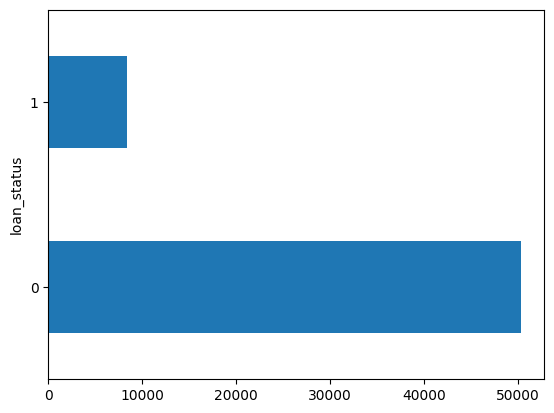

In [8]:
Y['loan_status'].value_counts().plot(kind='barh')

### The dataset is imbalanced in nature

### Technique 1: splitting the data on basis of stratified split

In [11]:
from sklearn.model_selection import train_test_split
xtrain1,xtest1,ytrain1,ytest1 = train_test_split(X,Y,train_size=0.75,stratify=Y)


In [12]:
xtrain1.shape

(43983, 11)

In [13]:
ytrain1.shape

(43983, 1)

In [14]:
xtrain1.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
9611,27,65000,MORTGAGE,9.0,PERSONAL,B,18000,9.99,0.28,N,5
5411,24,39000,RENT,2.0,MEDICAL,B,6000,11.36,0.15,N,2
3112,41,39000,RENT,2.0,DEBTCONSOLIDATION,D,5000,14.84,0.13,N,14
39447,23,21600,RENT,0.0,MEDICAL,A,5400,7.49,0.25,N,2
13060,29,83236,RENT,3.0,EDUCATION,D,7000,14.84,0.08,N,8


In [15]:
xtest1.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
24293,34,52700,MORTGAGE,3.0,HOMEIMPROVEMENT,B,14750,10.37,0.28,N,9
32722,22,55000,RENT,0.0,EDUCATION,B,10000,10.74,0.18,N,3
8204,37,85000,RENT,5.0,EDUCATION,A,6000,6.99,0.07,N,13
4459,22,40000,MORTGAGE,6.0,PERSONAL,A,8000,8.59,0.20,N,3
20995,23,33280,MORTGAGE,5.0,EDUCATION,B,10000,12.69,0.30,N,3


### Data Preprocessing and Data Cleaning

In [20]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer

cat = list(X.select_dtypes(include='object').columns) 
con = list(X.select_dtypes(include='number').columns)

num_pipe = make_pipeline(SimpleImputer(strategy='median'),
                         StandardScaler())

cat_pipe = make_pipeline(SimpleImputer(strategy='most_frequent'),
                         OneHotEncoder(handle_unknown='ignore',sparse_output=False))

pre = ColumnTransformer([('cat',cat_pipe,cat),
                         ('con',num_pipe,con)]).set_output(transform='pandas')

pre

,transformers,"[('cat', ...), ('con', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None


In [21]:
pre.fit(xtrain1)

,transformers,"[('cat', ...), ('con', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None


In [22]:
xtrain1_pre = pre.transform(xtrain1)
xtest1_pre = pre.transform(xtest1)

In [23]:
xtrain1_pre.head(2)

,cat__person_home_ownership_MORTGAGE,cat__person_home_ownership_OTHER,cat__person_home_ownership_OWN,cat__person_home_ownership_RENT,cat__loan_intent_DEBTCONSOLIDATION,cat__loan_intent_EDUCATION,cat__loan_intent_HOMEIMPROVEMENT,cat__loan_intent_MEDICAL,cat__loan_intent_PERSONAL,cat__loan_intent_VENTURE,...,cat__loan_grade_G,cat__cb_person_default_on_file_N,cat__cb_person_default_on_file_Y,con__person_age,con__person_income,con__person_emp_length,con__loan_amnt,con__loan_int_rate,con__loan_percent_income,con__cb_person_cred_hist_length
9611,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,-0.090270,0.02107,1.095252,1.579108,-0.230007,1.312898,-0.201084
5411,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,-0.587933,-0.64282,-0.687885,-0.579498,0.221288,-0.101920,-0.945741


### Model Building

In [24]:
from sklearn.linear_model import LogisticRegression
model1 = LogisticRegression(class_weight='balanced')
model1.fit(xtrain1_pre,ytrain1)

e:\DATA SCIENTIST\ML\repository\venv\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [25]:
model1.score(xtrain1_pre,ytrain1)

0.842461860264193

In [26]:
model1.score(xtest1_pre,ytest1)

0.8429272950484245

### Performance Metrics

In [27]:
from sklearn.metrics import f1_score,ConfusionMatrixDisplay,classification_report

ypreds =   model1.predict(xtest1_pre)

f1_data = f1_score(ytest1,ypreds)
f1_data

0.5984306887532694

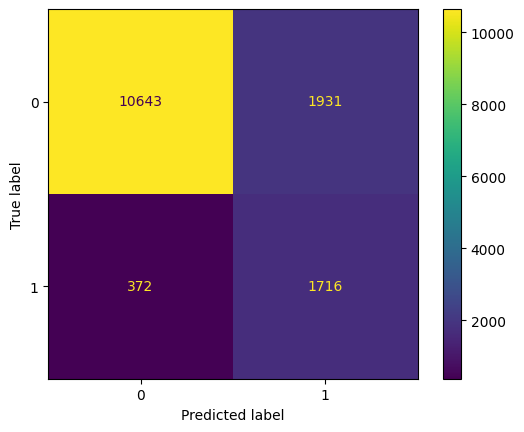

In [28]:
ConfusionMatrixDisplay.from_estimator(model1,xtest1_pre,ytest1)

In [29]:
print(classification_report(ytest1,ypreds))

              precision    recall  f1-score   support

           0       0.97      0.85      0.90     12574
           1       0.47      0.82      0.60      2088

    accuracy                           0.84     14662
   macro avg       0.72      0.83      0.75     14662
weighted avg       0.90      0.84      0.86     14662

